# MATH 4340 / COSC 4340: Numerical Methods for Differential Equations
# Notebook 12: Spectral Solutions to ODEs

### Professor: Dane Taylor
### Date: Spring 2024


In [1]:
%pylab inline
import timeit

from numpy.linalg import eig
from scipy.integrate import odeint

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


## 1. Spectral Decompositions and Matrix Exponential

In [2]:
A = array([[4, -2],
           [3, -3]])

In [3]:
lams,V=linalg.eig(A)
lams

array([ 3., -2.])

In [4]:
V

array([[0.89442719, 0.31622777],
       [0.4472136 , 0.9486833 ]])

In [5]:
v1 = array([2,1])
v2 = array([1,3])
print(v1/sqrt(5),v2/sqrt(10))

[0.89442719 0.4472136 ] [0.31622777 0.9486833 ]


#### Confirm that $A = VD V^{-1}$

In [6]:
V@diag(lams)@inv(V)

array([[ 4., -2.],
       [ 3., -3.]])

#### The matrix exponential is given by $e^{At} = Ve^{D t} V^{-1}$

In [7]:
t=1
V_inv = inv(V)
V@diag(exp(lams*t))@V_inv

array([[24.07557725, -7.98008066],
       [11.97012098, -3.85470504]])

## 2. Spectral Solutions to Linear ODEs

In [8]:
t0,T,N = 0,1,200
ti = linspace(t0,T,N+1) # times for the solution
h = ti[1] - ti[0]
x0 = [3,8] # initial conditions


#x = odeint(dxdt,x0,ti) # solve ODE using SciPy, default is 4th-order Runga-Kutta method
# forward Euler solution
x = zeros((N+1,2))
x[0] = x0
for i in range(N):
    x[i+1] = x[i] + h*A@x[i]

Text(0.5, 1.0, 'Foward Euler Solution')

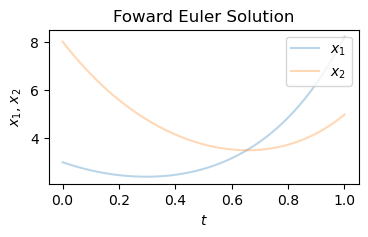

In [9]:
# plot this particular solution
fig, ax = plt.subplots(1, 1,figsize=(4,2))
ax.set_xlabel('$t$')
ax.set_ylabel('$x_1$, $x_2$')
ax.plot(ti,x,alpha=.3)
ax.legend(['$x_1$', '$x_2$'], loc='upper right');
plt.title('Foward Euler Solution')

#### spectral solution using matrix exponential

In [12]:
c= V_inv@x0 # coefficients for solution
c

array([0.4472136 , 8.22192192])

In [13]:
x_soln = zeros((N+1,2))
for i,t in enumerate(ti):
    x_soln[i] = V@diag(exp(lams*t))@c

Text(0.5, 1.0, 'Foward Euler and Spectral Solutions')

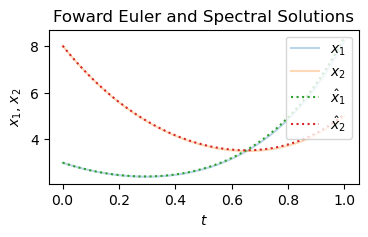

In [14]:
# plot this particular solution
fig, ax = plt.subplots(1, 1,figsize=(4,2))
ax.set_xlabel('$t$')
ax.set_ylabel('$x_1$, $x_2$')
ax.plot(ti,x,alpha=.3)
ax.plot(ti,x_soln,':')

ax.legend(['$x_1$', '$x_2$','$\hat{x}_1$', '$\hat{x}_2$'], loc='upper right');
plt.title('Foward Euler and Spectral Solutions')

Text(0, 0.5, '$x_2$')

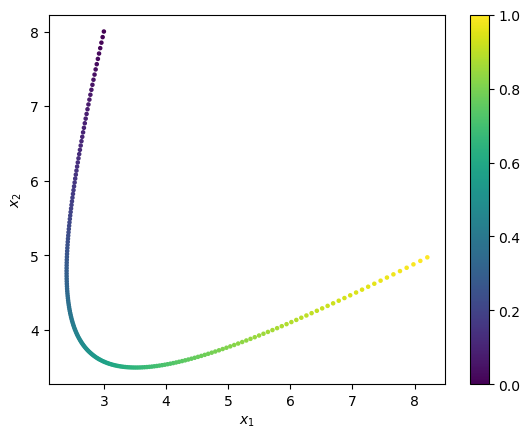

In [15]:
fig, ax = plt.subplots()
scatter_plot = ax.scatter(x[:,0], x[:,1],s=5,c=ti)
fig.colorbar(scatter_plot)
xlabel('$x_1$')
ylabel('$x_2$')

In [16]:
def make_quiver_plot(A,x):
    dx,dy = meshgrid(x,x)
    for j,x1 in enumerate(x):
        for i,x2 in enumerate(x):
            dx[i,j],dy[i,j] = A@[x1,x2]

    fig, ax = plt.subplots()
    q = ax.quiver(x,x,dx,dy)
    return fig,ax,q

Text(0, 0.5, '$x_2$')

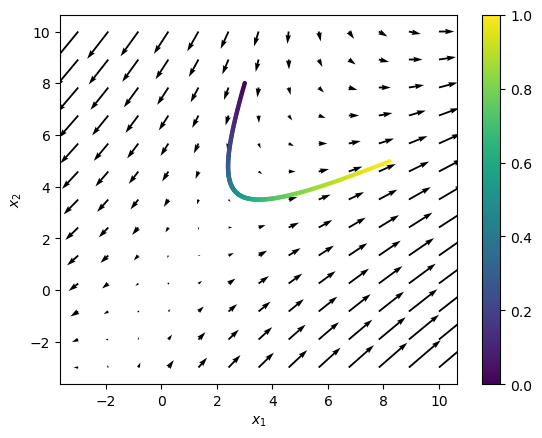

In [17]:
quiver_range = linspace(-3,10,13)
fig,ax,q = make_quiver_plot(A,quiver_range)

scatter_plot = ax.scatter(x[:,0], x[:,1],s=5,c=ti);
fig.colorbar(scatter_plot);
xlabel('$x_1$')
ylabel('$x_2$')

#### Note that the trajectory follows the eigenvectors

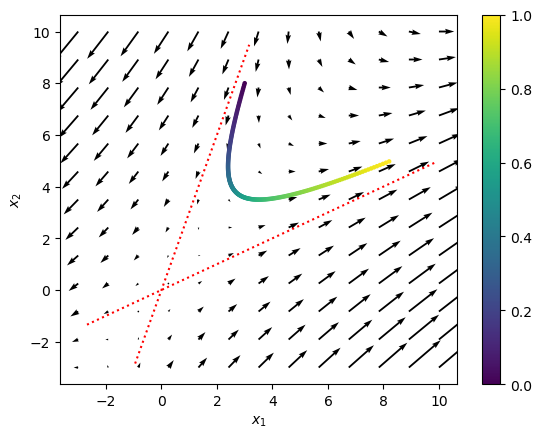

In [22]:
def sketch_2evecs(V,s):    
    plot([s[0]*V[0,0],s[1]*V[0,0]],[s[0]*V[1,0],s[1]*V[1,0]] ,'r:') 
    plot([s[2]*V[0,1],s[3]*V[0,1]],[s[2]*V[1,1],s[3]*V[1,1]] ,'r:');
    return

quiver_range = linspace(-3,10,13)
fig,ax,q = make_quiver_plot(A,quiver_range)
sketch_2evecs(V,[-3,11,-3,10])
scatter_plot = ax.scatter(x[:,0], x[:,1],s=5,c=ti);
fig.colorbar(scatter_plot);
xlabel('$x_1$')
ylabel('$x_2$');